# Multivariate Change Point Detection Regime Segmentation
Here we implement a multivariate change point detection approach. Unlike HMMs which assume hidden states that we transition between, change point detection looks for structural breaks in the statistical properties of the time series.

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

data_path = r'../../../data/synthetic_regime_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (2500, 11)


,Date,GSPC,Return,VIX,Drawdown,RSI_14,MACD_Hist,Consumer_Sentiment_ZScore,Gold,Oil,true_regime
0,2010-01-04,1000.000000,0.004965,14.152481,0.000000,NaN,0.000000,NaN,1800.000000,70.000000,bull
1,2010-01-05,1008.145477,0.008145,14.093172,0.000000,NaN,0.519825,NaN,1792.852257,69.041521,bull
2,2010-01-06,1005.876679,-0.002250,11.408714,-0.002250,NaN,0.672417,NaN,1789.745250,69.478473,bull
3,2010-01-07,1001.352353,-0.004498,14.339820,-0.006738,NaN,0.441361,NaN,1783.509265,68.643662,bull
4,2010-01-08,993.059949,-0.008281,16.465658,-0.014964,NaN,-0.259523,NaN,1784.869205,68.032626,bull


In [39]:
candidate_features = [
    'Return',
    'VIX', 'Drawdown',
    'RSI_14', 'MACD_Hist',
    'Consumer_Sentiment_ZScore',
    'Gold', 'Oil'
]

print(f"Candidate features ({len(candidate_features)}): {candidate_features}")

# Build working dataframe
df_work = df[['Date', price_col, ret_col] + [c for c in candidate_features if c not in [ret_col]]].copy()

print("\nMissing values BEFORE cleaning:")
print(df_work[candidate_features].isnull().sum())

df_work[candidate_features] = df_work[candidate_features].ffill(limit=5)
df_work[candidate_features] = df_work[candidate_features].interpolate(method='linear')

rows_before = len(df_work)
df_work = df_work.dropna(subset=candidate_features).reset_index(drop=True)
rows_after = len(df_work)

print(f"\nMissing values AFTER cleaning:")
print(df_work[candidate_features].isnull().sum())
print(f"\nRows dropped: {rows_before - rows_after} (from {rows_before} to {rows_after})")

Candidate features (8): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Gold', 'Oil']

Missing values BEFORE cleaning:
Return                        0
VIX                           0
Drawdown                      0
RSI_14                       14
MACD_Hist                     0
Consumer_Sentiment_ZScore    62
Gold                          0
Oil                           0
dtype: int64

Missing values AFTER cleaning:
Return                       0
VIX                          0
Drawdown                     0
RSI_14                       0
MACD_Hist                    0
Consumer_Sentiment_ZScore    0
Gold                         0
Oil                          0
dtype: int64

Rows dropped: 62 (from 2500 to 2438)


## Collinearity Analysis
Check for highly correlated features and remove redundant ones (threshold: |r| > 0.8), matching the GMM notebook's feature selection approach.

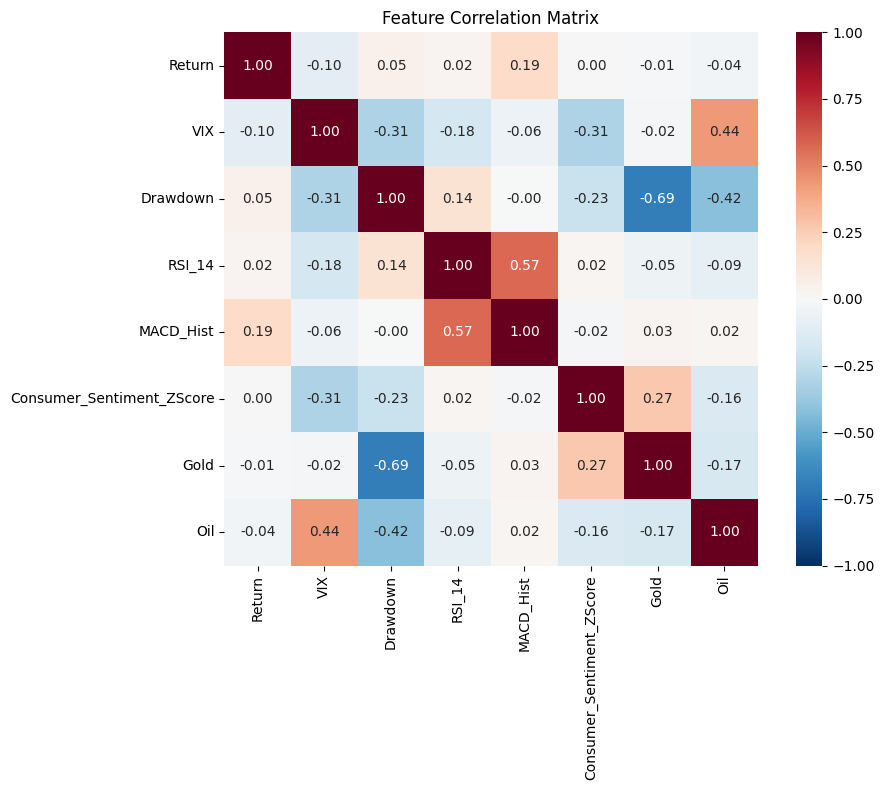

In [40]:
corr_matrix = df_work[candidate_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [41]:
collinearity_threshold = 0.8

upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > collinearity_threshold:
            high_corr_pairs.append((idx, col, round(val, 3)))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {collinearity_threshold}):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: r = {r}")
else:
    print("No highly correlated pairs found.")

features_to_drop = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in features_to_drop and f2 not in features_to_drop:
        count_f1 = sum(1 for a, b, _ in high_corr_pairs if a == f1 or b == f1)
        count_f2 = sum(1 for a, b, _ in high_corr_pairs if a == f2 or b == f2)
        drop = f1 if count_f1 >= count_f2 else f2
        features_to_drop.add(drop)

selected_features = [f for f in candidate_features if f not in features_to_drop]

print(f"\nFeatures removed due to collinearity: {sorted(features_to_drop)}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

No highly correlated pairs found.

Features removed due to collinearity: []
Selected features (8): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Gold', 'Oil']


## Standardise Selected Features

In [42]:
scaler = StandardScaler()
X_raw = df_work[selected_features].values
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X.shape}")
print(f"Post-standardisation means:  {X.mean(axis=0).round(6)}")
print(f"Post-standardisation stds:   {X.std(axis=0).round(6)}")

Feature matrix shape: (2438, 8)
Post-standardisation means:  [-0. -0.  0.  0.  0.  0.  0.  0.]
Post-standardisation stds:   [1. 1. 1. 1. 1. 1. 1. 1.]


Apply Ruptures (PELT) for CPD

In [43]:
print("Running Pelt search algorithm...")
model = "rbf"
algo = rpt.Pelt(model=model).fit(X)

# Higher penalty = fewer change points.
penalty = 5
result = algo.predict(pen=penalty)

print(f"Found {len(result) - 1} change points.")
print(f"Change point indices: {result[:-1]}")

Running Pelt search algorithm...
Found 39 change points.
Change point indices: [60, 85, 130, 185, 215, 240, 315, 335, 375, 460, 590, 620, 800, 810, 1070, 1100, 1125, 1140, 1170, 1190, 1215, 1225, 1270, 1375, 1430, 1455, 1485, 1505, 1525, 1585, 1660, 1705, 1860, 1885, 1955, 2020, 2170, 2345, 2365]


Map segments to Regimes (Bull/Bear)

In [44]:
df_work['regime'] = 'unknown'
df_work['segment'] = 0
df_work['true_regime'] = df['true_regime'].values[:len(df_work)]


start_idx = 0
for i, end_idx in enumerate(result):
    segment_data = df_work.iloc[start_idx:end_idx]
    
    # mean return for the segment
    mean_ret = segment_data[ret_col].mean()
    
    # simple heuristic: positive mean return -> bull, negative -> bear
    regime = 'bull' if mean_ret > 0 else 'bear'
    
    df_work.loc[start_idx:end_idx-1, 'regime'] = regime
    df_work.loc[start_idx:end_idx-1, 'segment'] = i
    
    start_idx = end_idx

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_work[['Date', 'regime', 'segment']], on='Date', how='left')
first_regime = df_work['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))


Regime Counts:
regime
bull    1490
bear    1010
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.596
bear    0.404
Name: proportion, dtype: float64


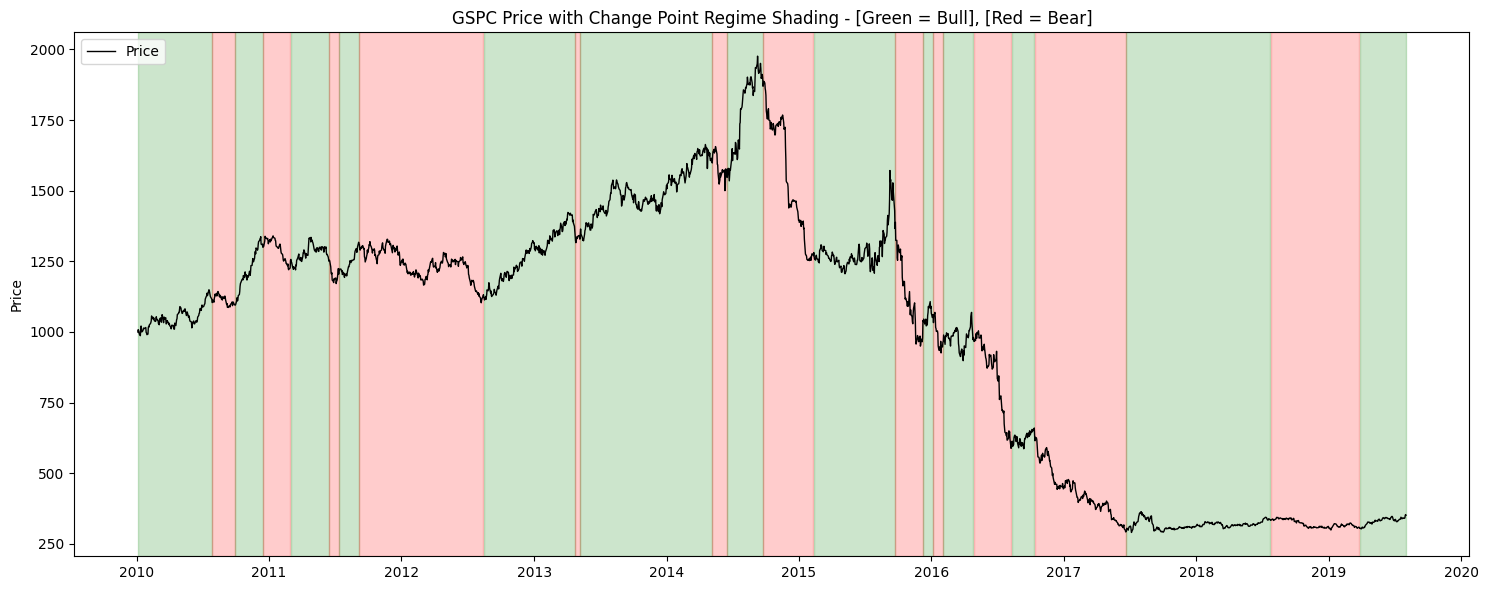

In [45]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Change Point Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [46]:
print(df.columns.tolist())

['Date', 'GSPC', 'Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Gold', 'Oil', 'true_regime', 'regime', 'segment']


In [47]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/synthetic/multivariate_changepoint_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/synthetic/multivariate_changepoint_labeled_dataset.csv


In [48]:
# =============================================================================
# EVALUATION CELL — Compare predicted regimes to synthetic ground truth
# =============================================================================
# Paste this cell at the END of each notebook (HMM, GMM, Changepoint)
# after the regime column has been assigned.
#
# Requirements:
#   - df must have a 'regime' column (predicted: 'bull' or 'bear')
#   - The synthetic CSV must have been loaded, so df also has 'true_regime'
#
# For HMM and Changepoint: the regime column is on df
# For GMM: the regime column is on df_work, so uncomment the line below:
# df = df_work.copy()  # <-- UNCOMMENT THIS FOR GMM NOTEBOOK ONLY

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# --- Align predicted and true labels ---
predicted = df['regime'].values
true = df['true_regime'].values

# Drop rows where either is NaN (shouldn't happen, but just in case)
mask = pd.notna(predicted) & pd.notna(true)
predicted = predicted[mask]
true = true[mask]

# --- Overall Accuracy ---
accuracy = accuracy_score(true, predicted)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy:.1%})")

# --- Per-regime Precision, Recall, F1 ---
print(f"\nClassification Report:")
print(classification_report(true, predicted, target_names=['bear', 'bull']))

# --- Confusion Matrix ---
cm = confusion_matrix(true, predicted, labels=['bear', 'bull'])
cm_df = pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull'])
print("Confusion Matrix:")
print(cm_df)

# --- Key insight: Bear recall (how many true crises were caught?) ---
bear_recall = recall_score(true, predicted, pos_label='bear')
bear_precision = precision_score(true, predicted, pos_label='bear')
print(f"\nBear Recall (crisis detection rate):  {bear_recall:.4f}")
print(f"Bear Precision (false alarm rate):    {bear_precision:.4f}")
print(f"  -> Of all true bear days, the model caught {bear_recall:.1%}")
print(f"  -> Of all days labelled bear, {bear_precision:.1%} were actually bear")

# --- Detection Lag (how many days after a true regime switch does the model react?) ---
regime_switches = np.where(true[1:] != true[:-1])[0] + 1
lags = []
for switch_idx in regime_switches:
    new_true_regime = true[switch_idx]
    # Look forward: how many days until predicted matches?
    for offset in range(0, min(60, len(true) - switch_idx)):
        if predicted[switch_idx + offset] == new_true_regime:
            lags.append(offset)
            break
    else:
        lags.append(np.nan)  # Never detected within 60 days

lags = np.array(lags, dtype=float)
valid_lags = lags[~np.isnan(lags)]

print(f"\n--- Detection Lag Analysis ---")
print(f"Total regime switches in ground truth: {len(regime_switches)}")
print(f"Switches detected within 60 days:      {len(valid_lags)}/{len(regime_switches)}")
if len(valid_lags) > 0:
    print(f"Mean detection lag:  {np.mean(valid_lags):.1f} days")
    print(f"Median detection lag: {np.median(valid_lags):.1f} days")

Overall Accuracy: 0.6372 (63.7%)

Classification Report:
              precision    recall  f1-score   support

        bear       0.36      0.58      0.45       625
        bull       0.82      0.66      0.73      1875

    accuracy                           0.64      2500
   macro avg       0.59      0.62      0.59      2500
weighted avg       0.71      0.64      0.66      2500

Confusion Matrix:
           Pred Bear  Pred Bull
True Bear        364        261
True Bull        646       1229

Bear Recall (crisis detection rate):  0.5824
Bear Precision (false alarm rate):    0.3604
  -> Of all true bear days, the model caught 58.2%
  -> Of all days labelled bear, 36.0% were actually bear

--- Detection Lag Analysis ---
Total regime switches in ground truth: 54
Switches detected within 60 days:      45/54
Mean detection lag:  9.9 days
Median detection lag: 0.0 days
